# Error Correction Model (ECM) Simulation

## Cointegration

The integration order of a time series is defined as the number differences required to produce a stationary time series and is denoted by $I(d)$ where $d$ is the number of differences. It follows that the integration order of a stationary time series is denoted by $I(0)$, so if $X_t$ is an $\text{ARMA}(p,q)$ process and stationary we write,</br>

$
\begin{align}
X_t \sim I(0).
\end{align}
\tag{1}
$

If $X_t^1$ is an $\text{ARIMA}(p,1,q)$ process with the first difference stationary then $\Delta X_t^1 \sim I(0)$ and it follows that $X^1_t \sim I(1)$. Similarly, if the second difference of $X_t^2$ is stationary then $X^2_t \sim I(2)$. Now, if $X_t \sim I(d)$ then,

$
\begin{align}
\varepsilon_t = a + b X_t \sim I(d).
\end{align}
\tag{2}
$

This makes sense because shifted and scaled a stationary process is stationary. Consider two $I(d)$ time series, $X_t$ and $Y_t$ where

$
\begin{align}
\varepsilon_t = Y_t - \left(\alpha + \beta X_t\right).
\end{align}
\tag{3}
$

It is usually true that $\varepsilon_t \sim I(d)$ but is also possible that $\varepsilon_t \sim I(b)$ where $b < d$. Consider the case where $X_t \sim I(1)$ and $Y_t \sim I(1)$. $X_t$ and $Y_t$ are said to be cointegrated if the following condition holds,

$
\begin{align}
\varepsilon_t = Y_t - \left(\alpha + \beta X_t\right) \sim I(0).
\end{align}
\tag{4}
$

The ADF test can be used to show that $\varepsilon_t$ is stationary and $\alpha$ and $\beta$ can be estimated using OLS.

## Error Correction Model (ECM)

Consider two cointegrated time series, $X_t \sim I(1)$ and $Y_t \sim I(1)$. It follows that,

$
\begin{align}
\varepsilon_t = Y_t - \left(\alpha + \beta X_t\right) \sim I(0).
\end{align}
\tag{5}
$

This can be written as,

$
\begin{align}
Y_t = \left(\alpha + \beta X_t\right) + \varepsilon_t.
\end{align}
\tag{6}
$

Since $X_t$ and $Y_t$ are $I(1)$ they have a variance that increases with time and since $\varepsilon_t$ is stationary it has a constant variance $X_t$ and $Y_t$ will eventually dominate. It follows that,

$
\begin{align}
Y_t = \left(\alpha + \beta X_t\right),
\end{align}
\tag{7}
$

thus $Y_t$ is a linear function of $X_t$. The desired relationship between $X_t$ and $Y_t$ is one in which all terms are $I(0)$. To achieve this assume a model of the form,

$
\begin{align}
Y_t - Y_{t-1} = \phi + \gamma_1 X_t + \gamma_2 X_{t-1} - \left( 1 - \mu \right) Y_{t-1} + \nu_t
\end{align}
\tag{8}
$

where $\nu_t \sim \text{Norma}(0, \sigma^2)$. Let $\Delta Y_t = Y_t - Y_{t-1}$ and $\Delta X_t = X_t - X_{t-1}$ and add $\gamma_1 X_{t-1} - \gamma_1 X_{t-1}$ to give,

$
\begin{align}
\Delta Y_t = \phi + \gamma_1 \Delta X_t + \left(1 - \mu\right)\left[Y_{t-1} - \frac{\gamma_1 + \gamma_2}{1 - \mu} X_{t-1} \right] + \nu_t
\end{align}
\tag{9}
$

and finally let,

$
\begin{align}
\beta &= \frac{\gamma_1 + \gamma_2}{1 - \mu} \\
\lambda &= 1 - \mu \\
\phi &= \delta - \lambda \alpha
\end{align}
\tag{10}
$

substituting into the previous expression gives letting $\gamma = \gamma_1$ gives the ECM,

$
\begin{align}
\Delta Y_t = \delta + \gamma \Delta X_t + \lambda \left( Y_{t-1} - \alpha - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{11}
$

Thus all terms are $I(0)$. For simplicity it will be assumed that $\alpha = \delta = 0$ giving,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{12}
$

## Simulation

The ECM simulation procedure is as follows,

1. Generate $X_t$ using an $\text{ARIMA}(1, 1, 0)$ process.
2. Compute $Y_t$ using the Error Correction Model.

## Mean Variance and Covariance

The mean, variance and covariance of the Error Correction Model are evaluated by noting that the residual is an $\text{AR}(1)$ process, namely,

$
\begin{align}
Y_{t-1} - \beta X_{t-1} \sim I(0)
\end{align}
\tag{13}
$

and recalling that the stationary mean and variance of $\text{AR}(1)$ for a process $Z_t$ is given by,

$
\begin{align}
\text{E}\left[ Z_t\right] &= 0 \\
\text{Var}\left[ Z_t\right] &= \frac{\sigma^2}{1 - \varphi^2}
\end{align}
\tag{14}
$

where $\varphi$ is the $\text{AR}(1)$ parameter for the underlying autoregressive process. For $X_t$ it follows that,

$
\begin{align}
\text{E}\left[ X_t\right] &= 0 \\
\text{Var}\left[ X_t\right] &= \frac{\sigma^2}{1 - \varphi^2}\left[t + 2 \sum_{k=1}^t \left(t - k\right) \varphi^k \right]
\end{align}
\tag{14}
$

and for $Y_t$,

$
\begin{align}
\text{E}\left[ Y_t\right] &= 0 \\
\text{Var}\left[ Y_t\right] &= \beta^2 \text{Var}\left[ X_t\right]
\end{align}
\tag{15}
$

Finally the covariance of $X_t$ and $Y_t$ is given by,

$
\begin{align}
\text{Cov}\left[X_t Y_t\right] &= \beta \text{Var}\left[ X_t\right]
\end{align}
\tag{16}
$

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, fcurve, fpoints, PlotType
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def estimate_residual_ar_parameters(xt, yt, β):
    εt = yt - β * xt
    return arima.compute_ar_estimate(εt, order=1)

def adf_test(xt, yt, β):
    εt = yt - β * xt
    return adf.compute_adf_test(εt)

def pacf_acf_plot(t, xt, yt, nlags, β, φ, σ=1.0):
    title = f"AR(1) ACF-PACF σ={σ}, $\\varphi=${φ}, β={β}"
    εt = yt - β * xt
    tacf, acf = stats.compute_acf(t, εt, nlags=nlags)
    tpacf, pacf = arima.compute_pacf(εt, nlags=nlags)
    comparison([acf, pacf], [tacf, tpacf], labels=["ACF", "PACF"], ylim=(-0.1, 1.0), title=title, figsize=(10, 6))
    
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

def cumu_xt_mean_plot(t, ensemble):
    title = f"ECM Simulation $x_t$ Ensemble Average Mean"
    t_ensemble, mean_ensemble = stats.compute_ensemble_mean(t, ensemble)
    t_mean, mean = ecm.compute_xt_mean(npts=len(t))
    fcurve(data=mean_ensemble, func=mean, x=t_ensemble, fx=t_mean, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_{x_t}$",
           labels=[r"$\langle x_t \rangle$", r"$\lim_{t \to \infty}\, \mu_{x_t}=0$"], title=title)

def cumu_yt_mean_plot(t, ensemble):
    title = f"ECM Simulation $y_t$ Ensemble Average Mean"
    t_ensemble, mean_ensemble = stats.compute_ensemble_mean(t, ensemble)
    t_mean, mean = ecm.compute_yt_mean(npts=len(t))
    fcurve(data=mean_ensemble, func=mean, x=t_ensemble, fx=t_mean, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_{y_t}$",
           labels=[r"$\langle x_t \rangle$", r"$\lim_{t \to \infty}\, \mu_{y_t}=0$"], title=title)

def cumu_xt_var_plot(t, ensemble, φ):
    title = f"ECM Simulation $x_t$ Ensemble Variance: φ={φ}"
    t_ensemble, var_ensemble = stats.compute_ensemble_var(t, ensemble)
    t_var, var = ecm.compute_xt_var(φ=φ, Δt=t[-1] / 10, npts=11)
    fpoints(data=var_ensemble, func=var, x=t_ensemble, fx=t_var, title_offset=0.025, xlabel=r"$t$", ylabel=r"$\sigma_t^2$",
            labels=[r"$Var[x_t]$", r"$\frac{\sigma^2}{1 - \varphi^2}\left[t + 2 \sum_{k=1}^t \left(t - k\right) \varphi^k \right]$"], title=title)
    
def cumu_yt_var_plot(t, ensemble, φ, β):
    title = f"ECM Simulation $y_t$ Time Asymptotic Variance φ={φ}, β={β}"
    t_ensemble, var_ensemble = stats.compute_ensemble_var(t, ensemble)
    t_var, var = ecm.compute_yt_var(φ=φ, β=β, Δt=t[-1] / 10, npts=11)
    fpoints(data=var_ensemble, func=var, x=t_ensemble, fx=t_var, title_offset=0.025, xlabel=r"$t$", ylabel=r"$\sigma_t^2$",
            labels=[r"$Var[y_t]$", r"$\beta^2 Var[x_t]$"], title=title)

def cumu_cov_plot(t, xt, yt, φ, β):
    title = f"ECM Simulation $x_t$ and $y_t$ Time Asymptotic Covariance φ={φ}, β={β}"
    t_ensemble, cov_ensemble = stats.compute_ensemble_cov(t, xt, yt)
    t_cov, cov = ecm.compute_cov(φ=φ, β=β, Δt=t[-1] / 10, npts=11)
    fpoints(data=cov_ensemble, func=cov, x=t_ensemble, fx=t_cov, title_offset=0.025, xlabel=r"$t$", ylabel=r"$\gamma_t$",
            labels=[r"$Cov[x_t y_t]$", r"$\beta Var[x_t]$"], title=title)

## Simulation Parameters

In [3]:
φ = 0.5
β = 0.5
λ = -0.25
γ = 0.75
npts = 1000

## Residual Stationarity

In [4]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)

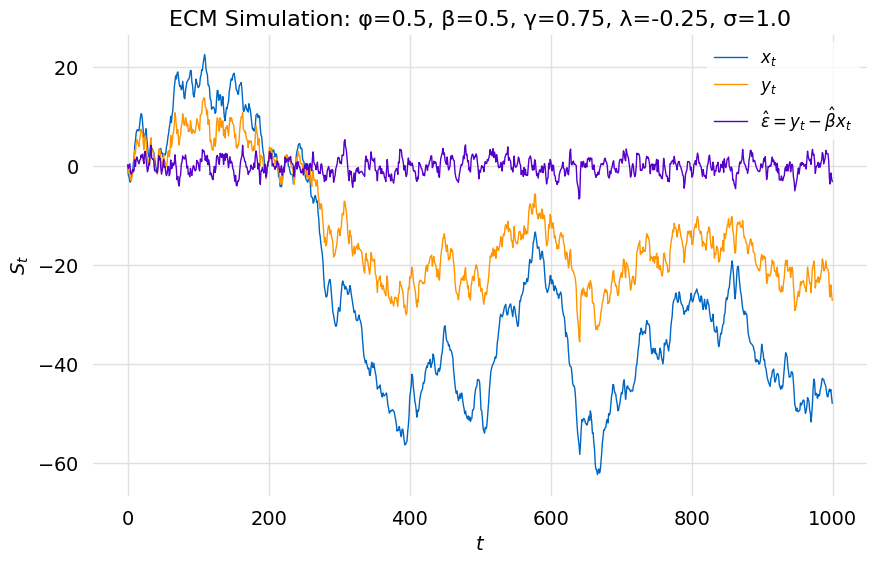

In [5]:
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [6]:
result, result_model = adf_test(xt, yt, β)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.2238      │
├────────────────┼───────────────┤
│ pvalue         │   2.48234e-20 │
├────────────────┼───────────────┤
│ Lags           │   4           │
├────────────────┼───────────────┤
│ Number Obs     │ 995           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [7]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$t$",
                "value": -11.223807807520101,
                "hyp_test_id": "cef4874d-a5e3-4a40-bbf6-9190c2ae3017"
            },
            "pval": {
                "label": "$p-value$",
                "value": 2.4823449837912696e-20,
                "hyp_test_id": "cef4874d-a5e3-4a40-bbf6-9190c2ae3017"
            },
            "params": [],
            "sig": {
                "label": "1%",
                "value": 0.01,
                "hyp_test_id": "cef4874d-a5e3-4a40-bbf6-9190c2ae3017"
            },
            "lower": {
                "label": "$t_L$",
                "value": -2.567990698719729,
                "hyp_test_id": "cef4874d-a5e3-4a40-bbf6-9190c2ae3017"
            },
            "upper": null,
            "hyp_test_id": "cef4874d-a5e3-4a40-bbf6-9190c2a

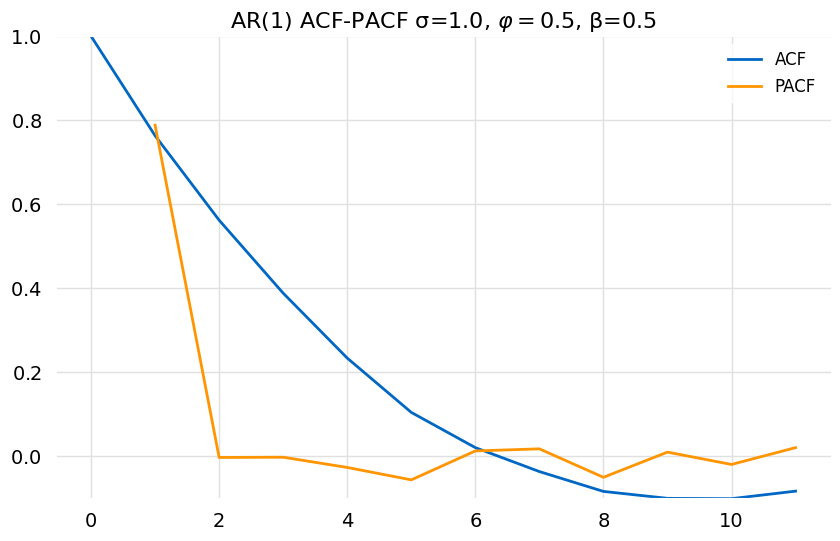

In [8]:
pacf_acf_plot(t, xt, yt, 11, β, φ)

In [9]:
result, result_model = estimate_residual_ar_parameters(xt, yt, β)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1472.294
Date:                Sun, 24 Sep 2023   AIC                           2950.587
Time:                        13:39:47   BIC                           2965.311
Sample:                             0   HQIC                          2956.183
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1520      0.143     -1.061      0.289      -0.433       0.129
ar.L1          0.7649      0.019     40.718      0.000       0.728       0.802
sigma2         1.1116      0.047     23.429      0.000       1.019       1.205
===================================================================================
Ljung-Box (L1) (Q):                   1.46   Jarque-Bera (JB):                 5.58
Prob(Q):                              0.23   Prob(JB):                         0.06
Heteroskedasticity (H):               0.90   Skew:                             0.15
Prob(H) (two-sided):                  0.32   Kurtosis:                         3.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Ensemble Analysis

In [10]:
nsim = 1000
source = lambda **kwargs: ecm.create_source(**kwargs)
t, ensemble = create_ensemble(source, nsim, φ=φ, β=β, λ=λ, γ=γ, npts=npts)
xt = ensemble[:,0,:]
yt = ensemble[:,1,:]
εt = yt - β * xt

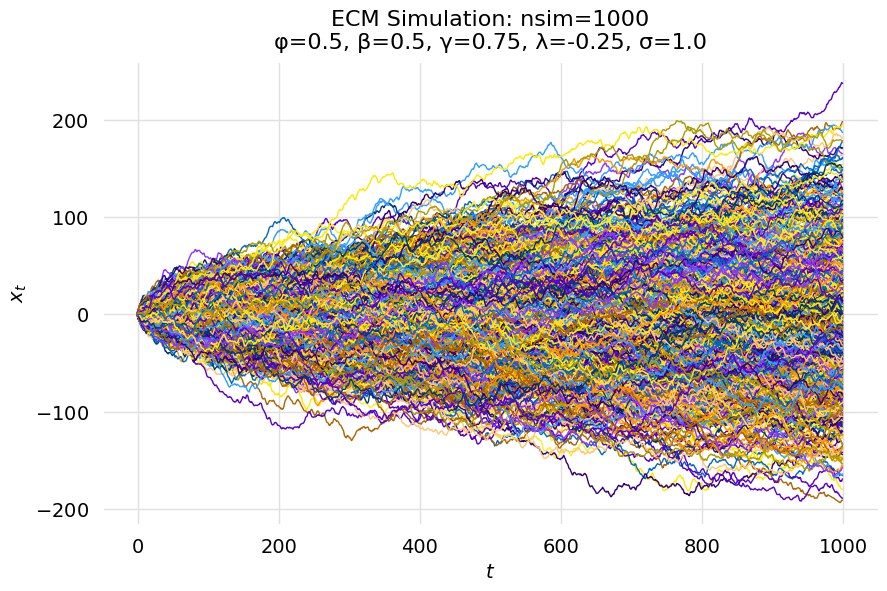

In [11]:
title = f"ECM Simulation: nsim={nsim}\nφ={φ}, β={β}, γ={γ}, λ={λ}, σ=1.0"
comparison(xt, t, title=title, xlabel=r"$t$", ylabel=r"$x_t$", lw=1, title_offset=0.01)

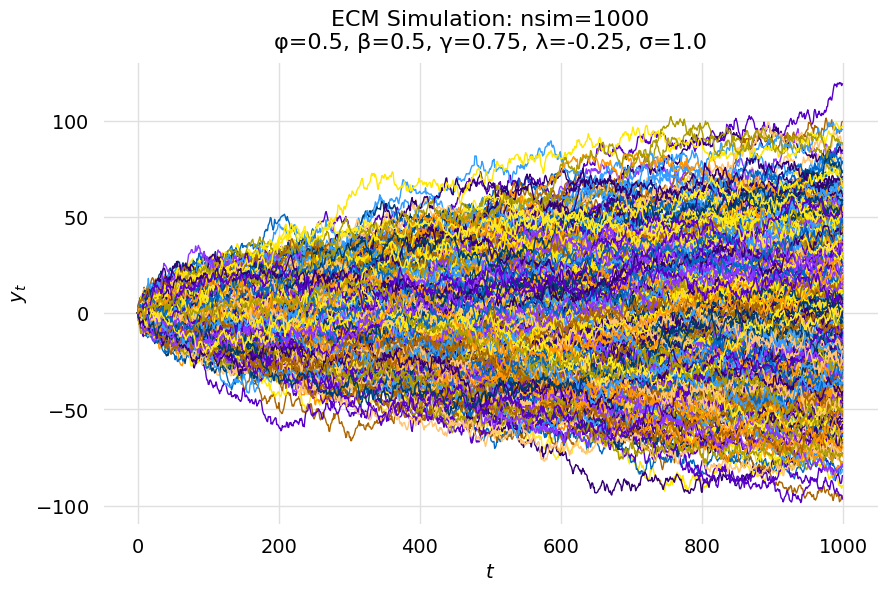

In [12]:
title = f"ECM Simulation: nsim={nsim}\nφ={φ}, β={β}, γ={γ}, λ={λ}, σ=1.0"
comparison(yt, t, title=title, xlabel=r"$t$", ylabel=r"$y_t$", lw=1, title_offset=0.01)

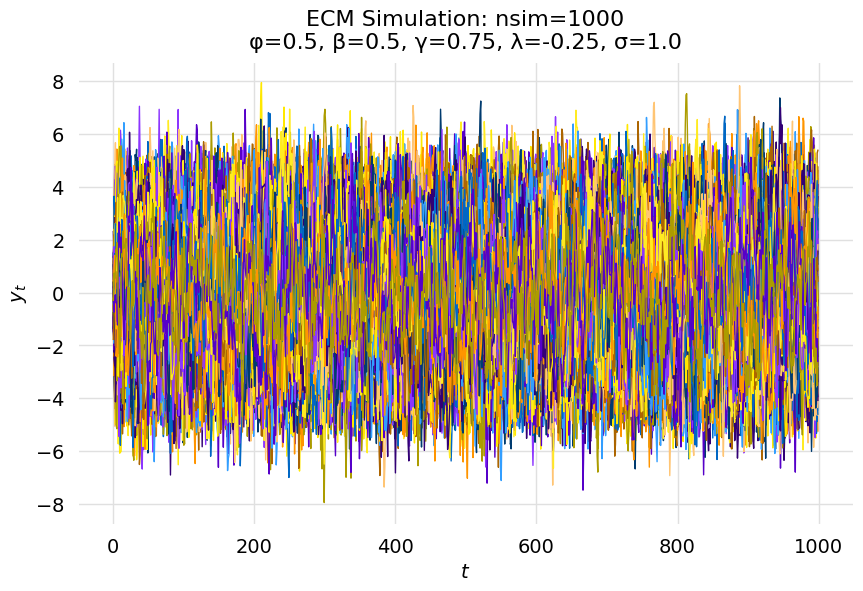

In [13]:
title = f"ECM Simulation: nsim={nsim}\nφ={φ}, β={β}, γ={γ}, λ={λ}, σ=1.0"
comparison(εt, t, title=title, xlabel=r"$t$", ylabel=r"$y_t$", lw=1, title_offset=0.01)

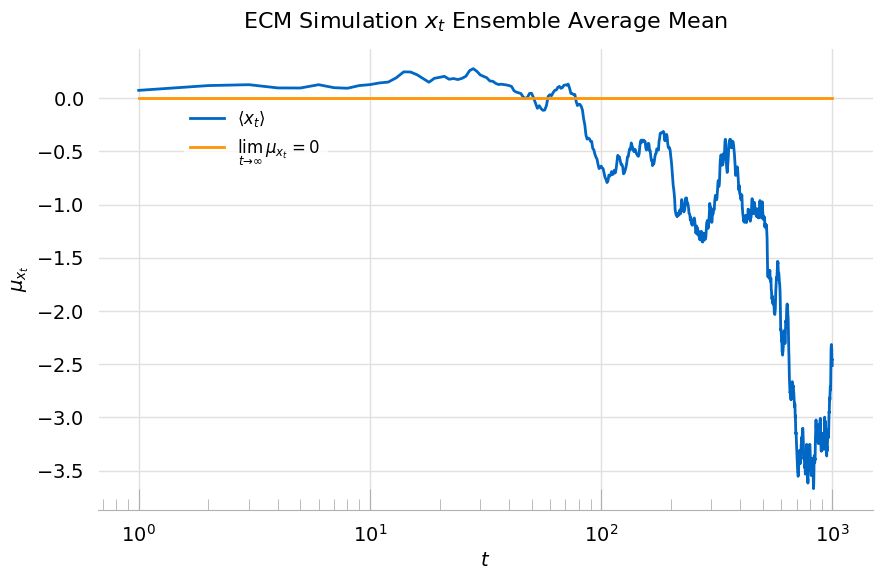

In [14]:
cumu_xt_mean_plot(t, xt)

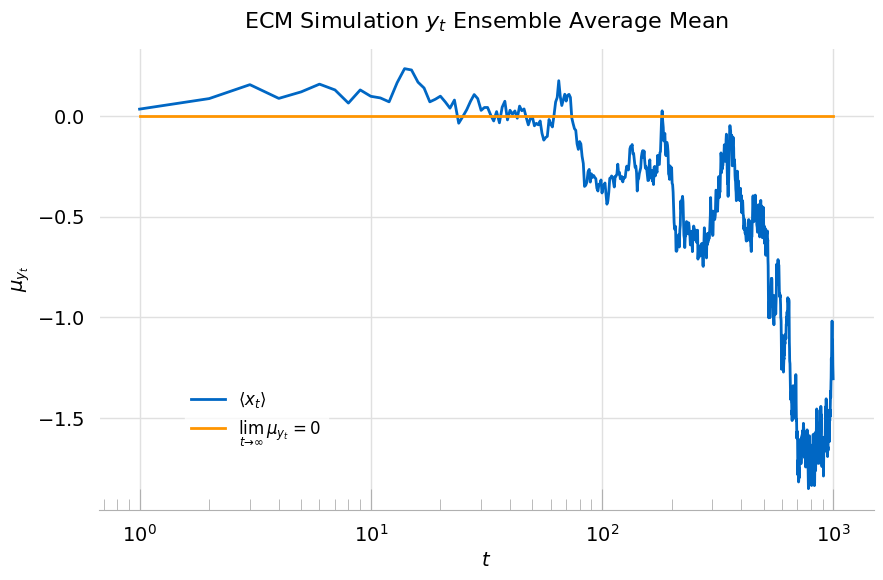

In [15]:
cumu_yt_mean_plot(t, yt)

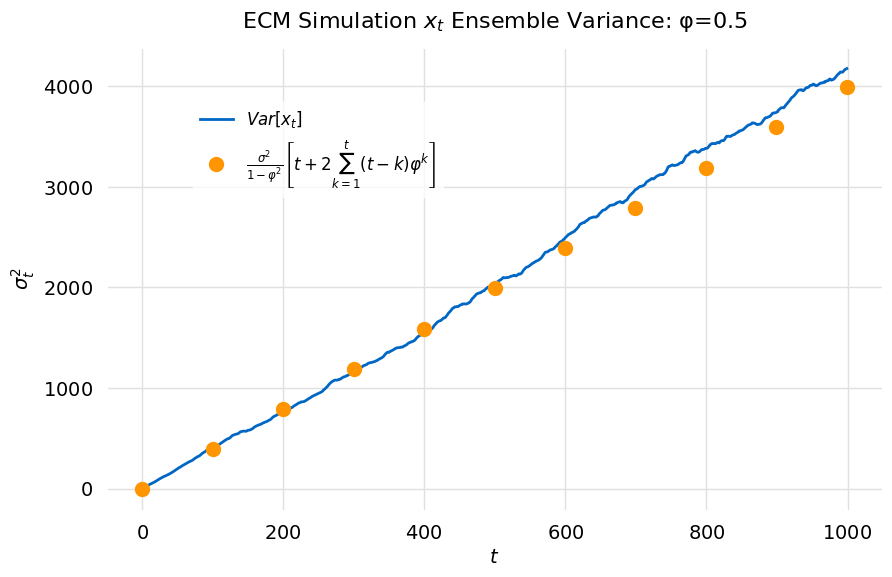

In [16]:
cumu_xt_var_plot(t, xt, φ)

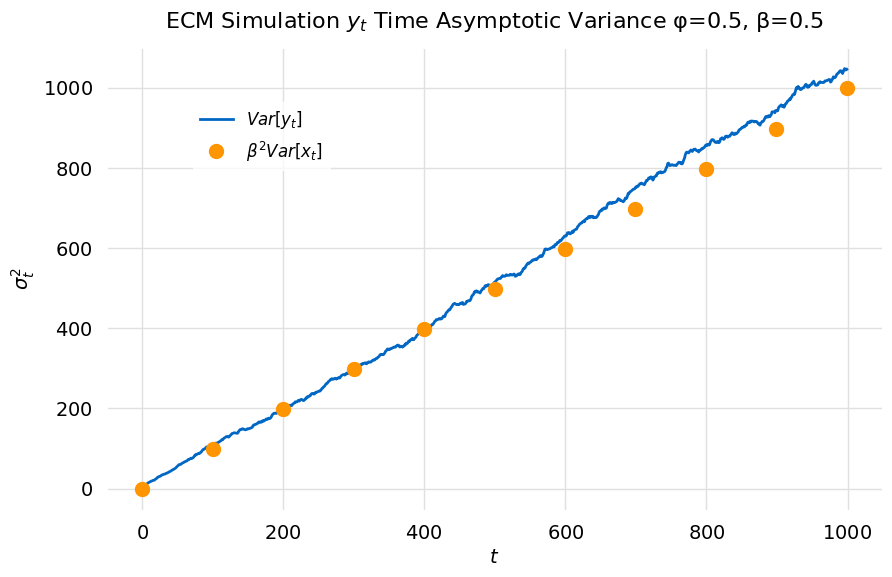

In [17]:
cumu_yt_var_plot(t, yt, φ, β)

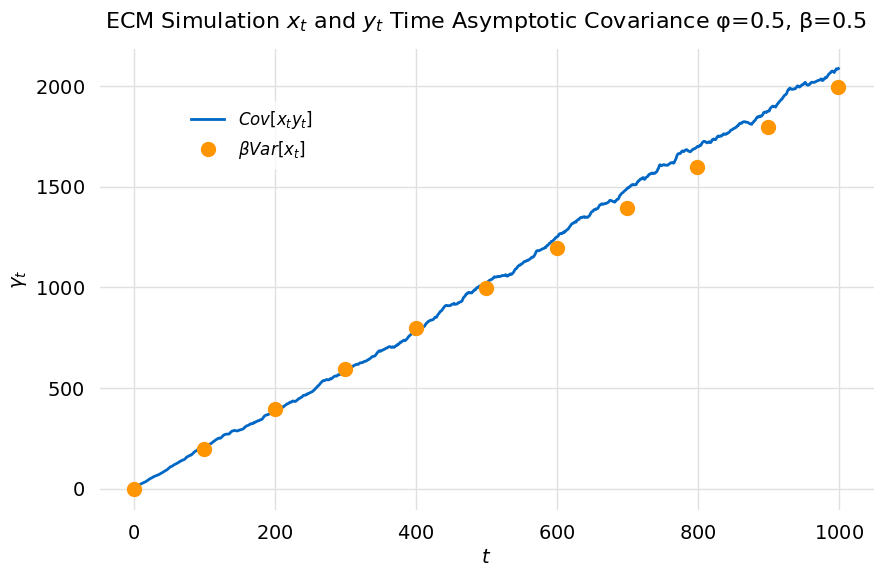

In [18]:
cumu_cov_plot(t, xt, yt, φ, β)